In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

data = load_wine()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

tree = DecisionTreeClassifier()

tree.fit(X_train, y_train)

pred_tree = tree.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, pred_tree))

Decision Tree Accuracy: 0.9444444444444444


In [3]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=10)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf))

Random Forest Accuracy: 0.9722222222222222


In [4]:
rf50 = RandomForestClassifier(n_estimators=50)
rf50.fit(X_train, y_train)
pred_rf50 = rf50.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf50))

rf200 = RandomForestClassifier(n_estimators=200)
rf200.fit(X_train, y_train)
pred_rf200 = rf200.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf200))

Random Forest Accuracy: 1.0
Random Forest Accuracy: 1.0


In [5]:
importances = rf.feature_importances_

features = data.feature_names

feat_df = pd.DataFrame({"feature": features,"importance": importances})

feat_df = feat_df.sort_values(by="importance", ascending=False)

print(feat_df)

                         feature  importance
12                       proline    0.171129
0                        alcohol    0.162611
9                color_intensity    0.147227
11  od280/od315_of_diluted_wines    0.145784
6                     flavanoids    0.129670
5                  total_phenols    0.101051
10                           hue    0.043027
1                     malic_acid    0.028183
2                            ash    0.024639
4                      magnesium    0.018724
3              alcalinity_of_ash    0.015279
8                proanthocyanins    0.011667
7           nonflavanoid_phenols    0.001009


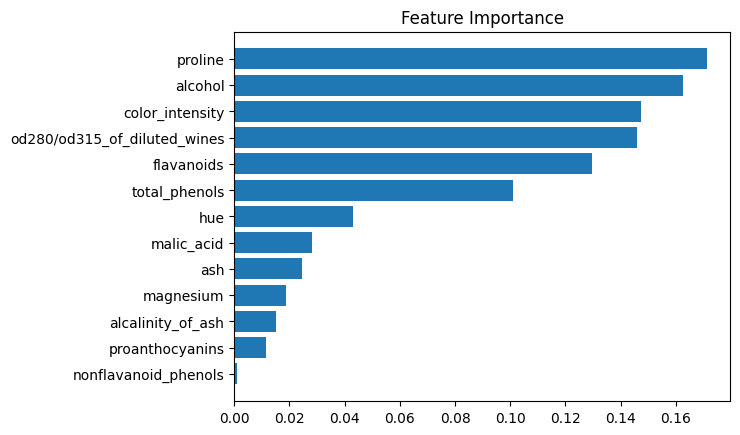

In [6]:
plt.barh(feat_df["feature"], feat_df["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()